In [1]:
!pip install gym

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import gym
from gym import spaces
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import time
import os
from tqdm import tqdm
from IPython.display import clear_output
import struct
import pandas as pd
import json

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [ ]:
trial_info = "PPO_1"

In [5]:
class ReactionWheelPendulumEnv(gym.Env):
    def __init__(self, threshold_angle, max_time, target_balance_time, time_step=0.01, simulate=False):
        super(ReactionWheelPendulumEnv, self).__init__()

        # Define action space (discrete motor speeds in RPM)
        self.rpm_to_rad_s = np.array([-400, -350, -300, -250, -200, -150, -100, -50, 0,
                                      50, 100, 150, 200, 250, 300, 350, 400]) * (np.pi / 30)
        self.action_space = spaces.Discrete(self.rpm_to_rad_s.shape[0])

        # Define observation space (state: [theta, theta_dot, omega, omega_dot])
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(3,), dtype=np.float32
        )

        # Parameters for the dynamics
        self.omega_n, self.zeta, self.k, self.cv = [38.099992002045674, 0.018765394864028125,
                                                    1443.4698748845892, 0.08390404004978032]
        self.Mp, self.lpcm, self.Ipo, self.Mr, self.lrcm, self.Ir, self.b = [
                                0.020373638605075156, 0.06504904820060829, 1.3078582648642452e-05,
                                0.155, 0.11, 0.00021453606127182941,
                                0.0008955443074902268]
        self.g = 9.8

        self.It = (self.Ipo + self.Mr*(self.lrcm**2) + self.Ir)
        self.Kmgl = (self.Mr*self.lrcm + self.Mp*self.lpcm)*self.g
        self.I = self.It + self.Ir

        self.threshold_angle = np.deg2rad(threshold_angle)
        self.time_step = time_step  # Simulation time step
        self.max_time = max_time
        self.max_steps = self.max_time/self.time_step
        self.target_balance_time = target_balance_time
        self.target_balance_steps = self.target_balance_time/self.time_step
        self.current_step = 0
        self.simulate=simulate

        # Initialize state
        self.state = None

        # Noise parameters
        self.noise_std = 0.01  # Standard deviation of Gaussian noise

        self.is_upright = False
        self.balance_steps = 0
        self.max_balance_steps = 0
        self.fell = False

    def dynamics(self, t, state, u):
        theta, theta_dot, omega, omega_dot = state
        theta_ddot = (
            (self.Kmgl / self.I) * np.sin(theta)
            - (self.b / self.I) * theta_dot
            - (self.Ir / self.I) * omega_dot
        )
        omega_ddot = (
            self.k * u
            - (2 * self.zeta * self.omega_n + self.cv * abs(omega_dot)) * omega_dot
            - (self.omega_n ** 2) * omega
        )
        return [theta_dot, theta_ddot, omega_dot, omega_ddot]

    def step(self, action):
        self.current_step += 1
        # Convert discrete action to rad/s
        u = self.rpm_to_rad_s[action]  # Map action to rad/s

        # Define time span for integration
        t_span = [self.current_time, self.current_time + self.time_step]

        # Solve dynamics equations
        sol = solve_ivp(self.dynamics, t_span, self.state, method='DOP853', args=(u,),
                        t_eval = [t_span[-1]], dense_output=True, rtol=1e-10, atol=1e-10)

        # Update state
        self.state = sol.y[:, -1]

        # Add noise to the state
        #self.state += np.random.normal(0, self.noise_std, size=self.state.shape)

        # Update current time
        self.current_time += self.time_step

        # Extract state variables
        theta, theta_dot, omega, omega_dot = self.state

        # Calculate reward
        theta_error = np.deg2rad(np.rad2deg(theta)%360)
        if theta_error > np.pi:
          theta_error = 2*np.pi - theta_error
        reward = -(theta_error**2)
        fell = False
        is_upright = abs(theta_error) < self.threshold_angle
        bonus = 0
        if is_upright:
          self.balance_steps += 1
          reward = 3 - (theta_error**2 + 0.001*theta_dot**2 + 0.005*u**2)
        else:
          if self.balance_steps > 0:
            fell = True
            # reward = -10
          self.balance_steps = 0

        if self.balance_steps > self.max_balance_steps:
          self.max_balance_steps = self.balance_steps

        # Define done condition (e.g., pendulum angle too large)
        terminated = True if self.balance_steps > self.target_balance_steps else False
        truncated = True if self.current_step >= self.max_steps else False

        if fell:
          # truncated = True
          reward = -100

        info = {
                "current_step": self.current_step,
                "balance_time": self.max_balance_steps,
        }

        # Return step information
        agent_state = np.copy(self.state[:-1])
        temp = np.rad2deg(agent_state[0])%360
        temp = temp if temp <= 180.0 else temp - 360.0
        agent_state[0] = np.deg2rad(temp)
        return np.array(agent_state, dtype=np.float32), reward, terminated, truncated, info


    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        initial_theta = np.pi
        initial_theta_dot = np.random.randint(-10, 10 + 1) * (np.pi / 30)

        self.state = np.array([
            initial_theta,          # Initial angle
            initial_theta_dot,      # Initial angular velocity
            0.0,                    # Initial wheel speed
            0.0                     # Initial wheel angular acceleration
        ], dtype=np.float32)

        self.current_time = 0
        self.current_step = 0
        self.is_upright = False
        self.balance_time = 0.0
        self.fell = False
        self.max_balance_time = 0

        # Return the initial observation
        agent_state = np.copy(self.state[:-1])
        temp = np.rad2deg(agent_state[0])%360
        temp = temp if temp <= 180.0 else temp - 360.0
        agent_state[0] = np.deg2rad(temp)
        return np.array(agent_state, dtype=np.float32), {}

    def render(self, mode='human'):
        pass

    def close(self):
        pass

In [6]:
class PPOMemory:
    def __init__(self, batch_size, max_size):
        self.max_size = max_size
        self.batch_size = batch_size
        self.ptr = 0  # Pointer for circular buffer
        self.size = 0  # Number of elements stored

        # Fixed-size numpy arrays
        self.states = np.zeros((max_size, 3), dtype=np.float32)  # 3 states (theta, theta_dot, omega)
        self.probs = np.zeros(max_size, dtype=np.float32)
        self.vals = np.zeros(max_size, dtype=np.float32)
        self.actions = np.zeros(max_size, dtype=np.int64)
        self.rewards = np.zeros(max_size, dtype=np.float32)
        self.dones = np.zeros(max_size, dtype=np.bool_)

    def store_memory(self, state, action, prob, val, reward, done):
        # Store new data at current pointer location
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.probs[self.ptr] = prob
        self.vals[self.ptr] = val
        self.rewards[self.ptr] = reward
        self.dones[self.ptr] = done

        # Move pointer for circular buffer (overwrite oldest data)
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def generate_batches(self):
        indices = np.arange(self.size)
        np.random.shuffle(indices)  # Shuffle the indices

        # Create batches using the shuffled indices
        batch_start = np.arange(0, self.size, self.batch_size)
        batches = [indices[i:i + self.batch_size] for i in batch_start]

        return self.states[:self.size], \
               self.actions[:self.size], \
               self.probs[:self.size], \
               self.vals[:self.size], \
               self.rewards[:self.size], \
               self.dones[:self.size], \
               batches

    def clear_memory(self):
        self.ptr = 0
        self.size = 0

In [7]:
class ActorNetwork(nn.Module):
  def __init__(self, n_actions, input_dims, alpha=3e-4, fc1_dims=16, fc2_dims=16):
    super(ActorNetwork, self).__init__()
    self.actor = nn.Sequential(
        nn.Linear(input_dims, fc1_dims),
        nn.ReLU(),
        nn.Linear(fc1_dims, fc1_dims),
        nn.ReLU(),
        nn.Linear(fc1_dims, fc1_dims),
        nn.ReLU(),
        nn.Linear(fc1_dims, n_actions),
        nn.Softmax(dim=-1)
    )

    self.optimizer = optim.Adam(self.parameters(), lr=alpha)
    self.device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    self.to(self.device)

  def forward(self, state):
    return self.actor(state)

class CriticNetwork(nn.Module):
  def __init__(self, input_dims, alpha=3e-4, fc1_dims=128, fc2_dims=128):
    super(CriticNetwork, self).__init__()
    self.critic = nn.Sequential(
        nn.Linear(input_dims, fc1_dims),
        nn.ReLU(),
        nn.Linear(fc1_dims, fc1_dims),
        nn.ReLU(),
        nn.Linear(fc1_dims, fc1_dims),
        nn.ReLU(),
        nn.Linear(fc1_dims, 1)
    )
    self.optimizer = optim.Adam(self.parameters(), lr=alpha)
    self.device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    self.to(self.device)

  def forward(self, state):
    value = self.critic(state)
    return value

In [10]:
class Agent:
  def __init__(self, n_actions, input_dims, gamma=0.9999, alpha=0.0003, gae_lambda=0.95,
               policy_clip=0.2, batch_size=64, n_epochs=10, ppo_memory_size=5000):
    self.gamma = gamma
    self.alpha = alpha
    self.policy_clip = policy_clip
    self.gae_lambda = gae_lambda
    self.batch_size = batch_size
    self.n_epochs = n_epochs

    self.actor = ActorNetwork(n_actions, input_dims, alpha)
    self.critic = CriticNetwork(input_dims, alpha)
    self.memory = PPOMemory(batch_size, ppo_memory_size)

    self.losses_logs = {
                        "actor_loss": [],
                        "critic_loss": [],
                        "total_loss": []
                       }

  def remember(self, state, action, prob, val, reward, done):
    self.memory.store_memory(state, action, prob, val, reward, done)

  def choose_action(self, observation):
    state = torch.tensor(np.array([observation]), dtype=torch.float).to(self.actor.device)
    dist = self.actor(state)
    dist = Categorical(dist)
    value = self.critic(state)
    action = dist.sample()

    prob = torch.squeeze(dist.log_prob(action)).item()
    action = torch.squeeze(action).item()
    val = torch.squeeze(value).item()

    return action, prob, val

  def compute_gae(self, rewards, values, dones):
    advantages = np.zeros_like(rewards)
    last_advantage = 0

    # We need values for s_t and s_{t+1}
    # For the terminal state, we should use a value of 0 if done is True
    next_value = 0  # Value of terminal state is 0

    for t in reversed(range(len(rewards))):
        # For the last step, we need to handle differently if it's terminal
        # dones[t] == 1, indicates terminal state
        if t == len(rewards) - 1:
            next_value = 0 if dones[t] else values[t]  # Terminal state has value 0
        else:
            next_value = values[t+1]

        # TD error: r_t + γV(s_{t+1}) - V(s_t)
        delta = rewards[t] + self.gamma * next_value * (1 - int(dones[t])) - values[t]

        # GAE calculation with lambda parameter
        advantages[t] = delta + self.gamma * self.gae_lambda * (1 - int(dones[t])) * last_advantage
        last_advantage = advantages[t]

    returns = advantages + values
    return advantages, returns

  def learn(self):
    actor_losses = []
    critic_losses = []
    total_losses = []
    for _ in range(self.n_epochs):
      state_arr, action_arr, old_prob_arr, val_arr, reward_arr, done_arr, batches = self.memory.generate_batches()

      advantage, returns = self.compute_gae(reward_arr, val_arr, done_arr)
      advantage = torch.tensor(advantage).to(self.actor.device)
      values = torch.tensor(val_arr).to(self.actor.device)
      returns = torch.tensor(returns).to(self.actor.device)
      for batch in batches:
        states = torch.tensor(state_arr[batch], dtype=torch.float).to(self.actor.device)
        old_probs = torch.tensor(old_prob_arr[batch]).to(self.actor.device)
        actions = torch.tensor(action_arr[batch]).to(self.actor.device)

        dist = self.actor(states)
        dist = Categorical(dist)
        critic_value = self.critic(states)

        critic_value = torch.squeeze(critic_value)

        new_probs = dist.log_prob(actions)
        prob_ratio = new_probs.exp()/old_probs.exp()
        weighted_probs = advantage[batch]*prob_ratio
        weighted_clipped_probs = torch.clamp(prob_ratio, 1-self.policy_clip, 1+self.policy_clip)*advantage[batch]

        actor_loss = -torch.min(weighted_probs, weighted_clipped_probs).mean()

        returns = advantage[batch] + values[batch]
        critic_loss = (returns - critic_value)**2
        critic_loss = critic_loss.mean()

        total_loss = actor_loss + 0.5*critic_loss

        self.actor.optimizer.zero_grad()
        self.critic.optimizer.zero_grad()
        total_loss.backward()
        self.actor.optimizer.step()
        self.critic.optimizer.step()

        actor_losses.append(actor_loss.item())
        critic_losses.append(critic_loss.item())
        total_losses.append(total_loss.item())

        self.losses_logs["actor_loss"].append(actor_loss.item())
        self.losses_logs["critic_loss"].append(critic_loss.item())
        self.losses_logs["total_loss"].append(total_loss.item())

    self.memory.clear_memory()
    # return np.mean(actor_losses), np.mean(critic_losses), np.mean(total_losses)

In [12]:
max_t=5
target_balance_time=2
t_step=0.010
env = ReactionWheelPendulumEnv(threshold_angle=10, max_time=max_t, target_balance_time=target_balance_time, time_step=t_step, simulate=False)
N = 10_000
agent = Agent(n_actions=env.action_space.n, input_dims=env.observation_space.shape[0],
              gamma=0.99, alpha=3e-4, gae_lambda=0.95, policy_clip=0.2, batch_size=64, n_epochs=10, ppo_memory_size=N)

iterations = 10_000

best_score = -1e6
score_history = []
episode_length = []

learn_iters = 0
avg_score = 0
n_steps = 0

successes = []
print_freq = 50
episode = 0
success_rate = 0
no_improvement_counter = 0

training_logs = {
    "episode": [],
    "episode_reward": [],
    "balance_time": [],
    "success": []
}

for i in range(iterations):
    observation = env.reset()[0]
    done = False
    score = 0
    while not done:
        action, prob, val = agent.choose_action(observation)
        observation_, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        if done:
            if truncated:
              successes.append(0)
              training_logs["success"].append(0)
            else:
              successes.append(1)
              training_logs["success"].append(1)
            episode += 1
            episode_length.append(info['balance_time'])

            training_logs["episode"].append(episode)
            training_logs["episode_reward"].append(score)
            training_logs["balance_time"].append(info["balance_time"])

        n_steps += 1
        score += reward
        agent.remember(observation, action, prob, val, reward, done)
        observation = observation_
        if n_steps % N == 0:
            agent.learn()
            learn_iters += 1
    score_history.append(score)

    if (episode) % print_freq == 0:
        mean_reward = np.mean(score_history[-print_freq:])
        current_success_rate = np.mean(successes[-print_freq:])
        mean_length = np.mean(episode_length[-print_freq:])
        print(f"Episode: {episode},  {learn_iters}, Mean Reward: {mean_reward:0.3f}, Success: {current_success_rate:0.1f}, Avg_len: {mean_length:0.1f}")

        if mean_reward > best_score:
            best_score = mean_reward
            no_improvement_counter = 0
        else:
            no_improvement_counter += 1

        if current_success_rate > success_rate:
            print("New Best Model Saved")
            torch.save(agent.actor.state_dict(), f"agent_{trial_info}.pth")
            success_rate = current_success_rate

        if no_improvement_counter >= 10 or success_rate > 0.9:
          break

with open(f"losses_{trial_info}.json", "w") as f:
    json.dump(agent.losses_logs, f)

with open(f"training_metrics_{trial_info}.json", "w") as f:
    json.dump(training_logs, f)

Episode: 50,  2, Mean Reward: -4469.391, Success: 0.0, Avg_len: 0.0
Episode: 100,  5, Mean Reward: -4240.744, Success: 0.0, Avg_len: 0.0
Episode: 150,  7, Mean Reward: -3886.406, Success: 0.0, Avg_len: 0.0
Episode: 200,  10, Mean Reward: -3234.864, Success: 0.0, Avg_len: 0.0
Episode: 250,  12, Mean Reward: -2656.929, Success: 0.0, Avg_len: 0.0
Episode: 300,  15, Mean Reward: -2188.107, Success: 0.0, Avg_len: 27.7
Episode: 350,  17, Mean Reward: -1932.802, Success: 0.0, Avg_len: 37.5
Episode: 400,  20, Mean Reward: -1852.330, Success: 0.0, Avg_len: 93.6
Episode: 450,  22, Mean Reward: -1807.660, Success: 0.0, Avg_len: 105.0
Episode: 500,  25, Mean Reward: -1769.474, Success: 0.0, Avg_len: 120.1
Episode: 550,  27, Mean Reward: -1744.158, Success: 0.0, Avg_len: 126.0
Episode: 600,  30, Mean Reward: -1730.007, Success: 0.0, Avg_len: 126.0
Episode: 650,  32, Mean Reward: -1739.069, Success: 0.0, Avg_len: 126.0
Episode: 700,  35, Mean Reward: -1691.775, Success: 0.0, Avg_len: 126.0
Episode: 

In [13]:
# Load the file
with open(f"losses_{trial_info}.json", "r") as f:
    losses_logs = json.load(f)

with open(f"training_metrics_{trial_info}.json", "r") as f:
    training_logs = json.load(f)

actor_loss = losses_logs["actor_loss"]
critic_loss = losses_logs["critic_loss"]
total_loss = losses_logs["total_loss"]

reward = training_logs["episode_reward"]
balance_time = training_logs["balance_time"]

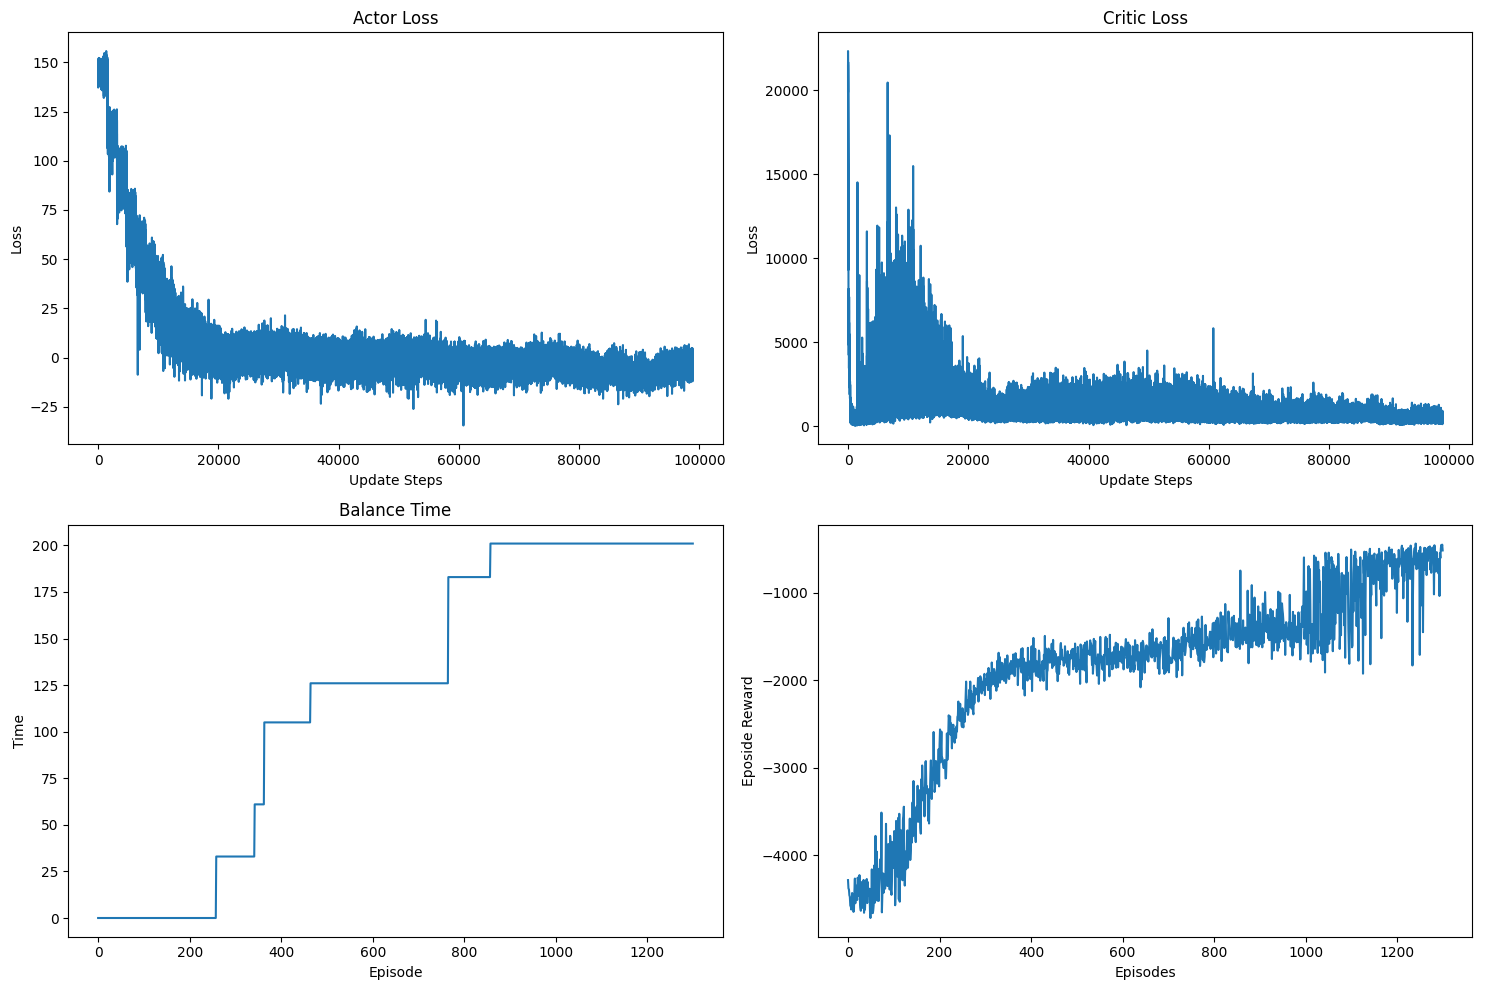

In [14]:
def plot_results(actor_loss, critic_loss, total_loss, reward, balance_time):
    plt.figure(figsize=(15, 10))

    # Plot Q loss
    plt.subplot(2, 2, 1)
    plt.plot(actor_loss)
    plt.title("Actor Loss")
    plt.xlabel("Update Steps")
    plt.ylabel("Loss")

    # Plot pi loss
    plt.subplot(2, 2, 2)
    plt.plot(critic_loss)
    plt.title("Critic Loss")
    plt.xlabel("Update Steps")
    plt.ylabel("Loss")

    # Plot episode rewards
    plt.subplot(2, 2, 3)
    plt.plot(balance_time)
    plt.title("Balance Time")
    plt.xlabel("Episode")
    plt.ylabel("Time")

    # Plot success rate (moving average)
    plt.subplot(2, 2, 4)
    plt.plot(reward)
    plt.xlabel("Episodes")
    plt.ylabel("Eposide Reward")

    plt.tight_layout()
    plt.savefig(f"training_results_{trial_info}.png")
    plt.show()

plot_results(actor_loss, critic_loss, total_loss, reward, balance_time)

In [15]:
def export_weights_to_c_header(model, output_file=f"weights_{trial_info}.h"):
    input_neurons = env.observation_space.shape[0]
    hidden_neurons = 16
    output_neurons = env.action_space.n
    # Extract weights and biases
    weights = []
    biases = []

    for name, param in model.named_parameters():
        if 'weight' in name:
            weights.append(param.detach().cpu().numpy())
        elif 'bias' in name:
            biases.append(param.detach().cpu().numpy())

    # Generate C header file
    with open(output_file, 'w') as f:
        f.write("#ifndef NETWORK_WEIGHTS_H\n")
        f.write("#define NETWORK_WEIGHTS_H\n\n")
        end_line = "{\n"

        # Write input layer weights
        f.write(f"const float input_weights[{hidden_neurons}][{input_neurons}] = {end_line}    ")
        for i in range(hidden_neurons):
            f.write("    {")
            for j in range(input_neurons):
                f.write(f"{weights[0][i][j]:.6f}f")
                if j < input_neurons-1:
                    f.write(", ")
            f.write("},\n")
        f.write("};\n\n")

        # Write input layer bias
        f.write(f"const float input_bias[{hidden_neurons}] = {end_line}    ")
        for i in range(hidden_neurons):
            f.write(f"{biases[0][i]:.6f}f")
            if i < hidden_neurons-1:
                f.write(", ")
            if (i + 1) % 8 == 0:
                f.write("\n    ")
        f.write("\n};\n\n")

        # Write hidden layer 1 weights
        f.write(f"const float hidden1_weights[{hidden_neurons}][{hidden_neurons}] = {end_line}    ")
        for i in range(hidden_neurons):
            f.write("    {")
            for j in range(hidden_neurons):
                f.write(f"{weights[1][i][j]:.6f}f")
                if j < hidden_neurons-1:
                    f.write(", ")
            f.write("},\n")
        f.write("};\n\n")

        # Write hidden layer 1 bias
        f.write(f"const float hidden1_bias[{hidden_neurons}] = {end_line}    ")
        for i in range(hidden_neurons):
            f.write(f"{biases[1][i]:.6f}f")
            if i < hidden_neurons-1:
                f.write(", ")
            if (i + 1) % 8 == 0:
                f.write("\n    ")
        f.write("\n};\n\n")

        # Write hidden layer 2 weights
        f.write(f"const float hidden2_weights[{hidden_neurons}][{hidden_neurons}] = {end_line}    ")
        for i in range(hidden_neurons):
            f.write("    {")
            for j in range(hidden_neurons):
                f.write(f"{weights[2][i][j]:.6f}f")
                if j < hidden_neurons-1:
                    f.write(", ")
            f.write("},\n")
        f.write("};\n\n")

        # Write hidden layer 2 bias
        f.write(f"const float hidden2_bias[{hidden_neurons}] = {end_line}    ")
        for i in range(hidden_neurons):
            f.write(f"{biases[2][i]:.6f}f")
            if i < hidden_neurons-1:
                f.write(", ")
            if (i + 1) % 8 == 0:
                f.write("\n    ")
        f.write("\n};\n\n")

        # Write output layer weights
        f.write(f"const float output_weights[{output_neurons}][{hidden_neurons}] = {end_line}    ")
        for i in range(output_neurons):
            f.write("    {")
            for j in range(hidden_neurons):
                f.write(f"{weights[3][i][j]:.6f}f")
                if j < hidden_neurons-1:
                    f.write(", ")
            f.write("},\n")
        f.write("};\n\n")

        # Write output layer bias
        f.write(f"const float output_bias[{output_neurons}] = {end_line}    ")
        for i in range(output_neurons):
            f.write(f"{biases[3][i]:.6f}f")
            if i < output_neurons-1:
                f.write(", ")
        f.write("\n};\n\n")

        f.write("#endif // NETWORK_WEIGHTS_H\n")

# Export weights
model = ActorNetwork(n_actions=env.action_space.n, input_dims=env.observation_space.shape[0])
weights = torch.load(f"agent_{trial_info}.pth", map_location=torch.device('cpu'))
model.load_state_dict(weights)
export_weights_to_c_header(model)

180.0 0.0
Success
Episode Reward: -106.38


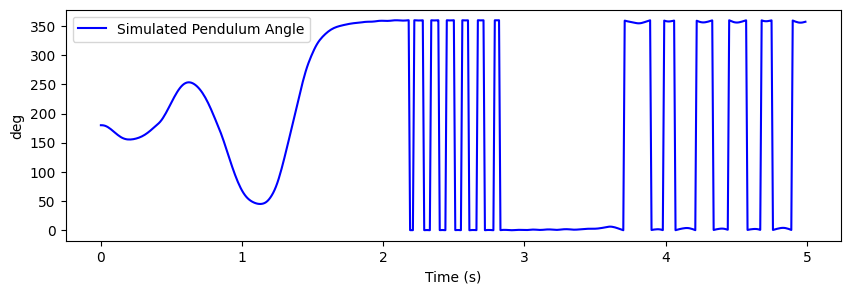

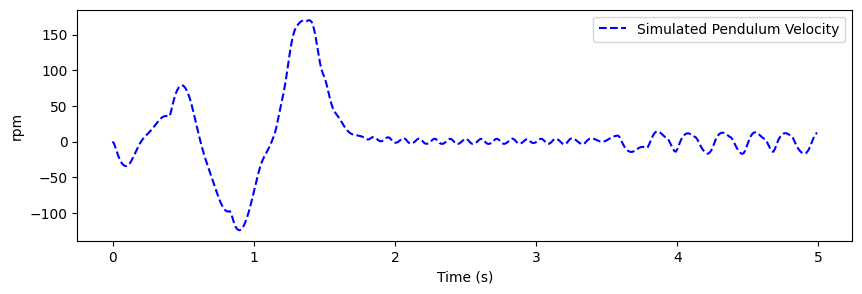

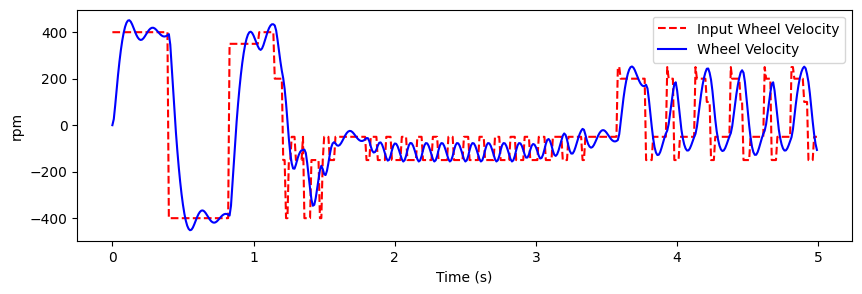

In [21]:
max_t=5
target_balance_time=2
t_step=0.010
env2 = ReactionWheelPendulumEnv(threshold_angle=10, max_time=max_t, target_balance_time=target_balance_time, time_step=t_step, simulate=False)
filepath = f"agent_{trial_info}.pth"
model = ActorNetwork(n_actions=env2.action_space.n, input_dims=env2.observation_space.shape[0])
weights = torch.load(filepath, map_location=torch.device('cpu'))
model.load_state_dict(weights)
def simulate(ang, vel, model):
  model.eval()
  total_rewards = []
  simulation_length = max_t/env2.time_step # in seconds
  state, _ = env2.reset()
  env2.state[0] = np.deg2rad(ang)
  env2.state[1] = vel*(np.pi/30)
  state[0], state[1] = env2.state[0], env2.state[1]
  print(np.rad2deg(env2.state[0]), env2.state[1]*(30/np.pi))
  episode_reward = 0
  terminated = False
  truncated = False
  i = 0
  rpm = np.copy(env2.rpm_to_rad_s) * (30/np.pi)
  pAngles, pVelocities, wAngles, wVelocities, iVelocities = [], [], [0], [], []
  failed = False
  while not failed:
      i += 1
      # Convert state to tensor
      state_tensor = torch.FloatTensor(state).unsqueeze(0).to(model.device)

      # Get action from model
      with torch.no_grad():
          dist = model(state_tensor).cpu()  # Get action distribution
          action = dist.argmax().detach().numpy()

      pAngle, pVelocity, wVelocity, iVelocity = state[0], state[1], state[2], rpm[action]
      pAngles.append(pAngle)
      pVelocities.append(pVelocity)
      wAngles.append(wAngles[-1]+wVelocity*env2.time_step)
      wVelocities.append(wVelocity)
      iVelocities.append(iVelocity)

      # Take action in environment
      state, reward, terminated, truncated, info = env2.step(action)
      episode_reward += reward
      # If the pendulum was not able to reach vertical position in 3 seconds,
      # Or reaching vertical position but falling before 2 seconds are passed (after reaching vertical),
      # the episode terminates and agent fails
      failed = truncated and not terminated
      # If the agent balances the pendulum for the specified length of time, we break the loop
      if i >= simulation_length:
        print("Success")
        break
      if failed:
        print("Failed")
        break

  print(f"Episode Reward: {episode_reward:.2f}")

  env2.close()
  pAngles, pVelocities, wVelocities, iVelocities = np.array(pAngles), np.array(pVelocities), np.array(wVelocities), np.array(iVelocities)
  wAngles = np.array(wAngles)

  samplingInterval = env2.time_step*1000 # in ms
  timeStep = env2.time_step
  simulationTime = len(pAngles)
  TIME = np.arange(len(pAngles)) * timeStep

  plt.figure(figsize=(10, 3))
  plt.plot(TIME, np.rad2deg(pAngles)%360, label="Simulated Pendulum Angle", color="blue")
  plt.xlabel("Time (s)")
  plt.ylabel("deg")
  plt.legend()

  plt.figure(figsize=(10, 3))
  plt.plot(TIME, pVelocities*(30/np.pi), label="Simulated Pendulum Velocity", color="blue", linestyle="--")
  plt.xlabel("Time (s)")
  plt.ylabel("rpm")
  plt.legend()

  plt.figure(figsize=(10, 3))
  plt.plot(TIME, iVelocities, label="Input Wheel Velocity", color="red", linestyle="--")
  plt.plot(TIME, wVelocities*(30/np.pi), label="Wheel Velocity", color="blue")
  plt.xlabel("Time (s)")
  plt.ylabel("rpm")
  plt.legend()

  plt.show()

  simulations_logs = {
      "time_s": TIME,
      "Theta": np.rad2deg(pAngles) % 360,
      "Theta_dot": pVelocities * (30/np.pi),
      "output speed": wVelocities * (30/np.pi),
      "input speed": iVelocities
  }
  pd.DataFrame(simulations_logs).to_csv(f"simulation_metrics_{trial_info}.csv", index=False)
  return pAngles, pVelocities, wAngles, wVelocities

ang = 180
vel = 0
pAngles, pVelocities, wAngles, wVelocities = simulate(ang, vel, model)

In [17]:
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib as mpl

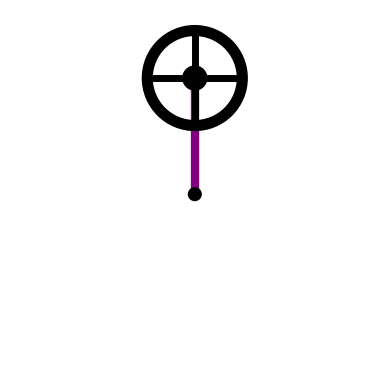

In [22]:
class PendulumAnimation:
  def __init__(self, ARM_LENGTH, ARM_THICKNESS, OUTER_RADIUS, WHEEL_THICKNESS, HUB_RADIUS, SPOKE_WIDTH, ORIGIN_RADIUS):
    self.arm_length = ARM_LENGTH
    self.arm_thickness = ARM_THICKNESS
    self.wheel_radius = OUTER_RADIUS
    self.wheel_thickness = WHEEL_THICKNESS
    self.hub_radius = HUB_RADIUS
    self.spoke_width = SPOKE_WIDTH
    self.origin_radius = ORIGIN_RADIUS

    self.pivot = (0, 0)
    self.pendulum_end = (0, ARM_LENGTH)
    self.wheel_center = (0, ARM_LENGTH)

    self.setup_plot()

  def setup_plot(self):
    self.fig, self.ax = plt.subplots()
    scale = 0.35
    self.ax.set_xlim(-scale, scale)
    self.ax.set_ylim(-scale, scale)
    self.ax.set_aspect('equal')
    self.ax.grid(False)
    self.ax.axis('off')

    self.pendulum_line = Line2D([], [], lw=self.arm_thickness, color='purple', zorder=1)
    self.origin = Circle((0, 0), self.origin_radius, color='black', zorder=2)
    self.spokes = [Line2D([], [], color='black', lw=self.spoke_width, zorder=3) for _ in range(4)]
    self.hub = Circle(self.wheel_center, self.hub_radius, color='black', lw=3, zorder=4)
    self.outer_wheel = Circle(self.wheel_center, self.wheel_radius, fill=False, color='black', lw=self.wheel_thickness, zorder=5)

    self.ax.add_line(self.pendulum_line)
    self.ax.add_patch(self.origin)
    self.ax.add_patch(self.hub)
    self.ax.add_patch(self.outer_wheel)
    for spoke in self.spokes:
        self.ax.add_line(spoke)

  def update(self, state):
    pendulum_angle, _, wheel_angle, _ = state

    x_center, y_center = -self.arm_length * np.sin(pendulum_angle), self.arm_length * np.cos(pendulum_angle)
    self.wheel_center = (x_center, y_center)

    self.pendulum_line.set_data([x_center, 0], [y_center, 0])
    self.origin.center = (0, 0)
    self.hub.center = self.wheel_center
    for i, spoke in enumerate(self.spokes):
        angle = wheel_angle + i * (2*np.pi/len(self.spokes))
        spoke.set_data([x_center, x_center + self.wheel_radius * np.cos(angle)],
                        [y_center, y_center + self.wheel_radius * np.sin(angle)])
    self.outer_wheel.center = self.wheel_center

    return self.pendulum_line, self.origin, *self.spokes, self.hub, self.outer_wheel

  def pendulum_anime_init(self):
    self.update(np.zeros(4))
    return self.pendulum_line, self.origin, *self.spokes, self.hub, self.outer_wheel

  def show(self):
    plt.show()

ARM_LENGTH = 0.22
ARM_THICKNESS = 6
OUTER_RADIUS = 0.09
WHEEL_THICKNESS = 8
HUB_RADIUS = 0.02
SPOKE_WIDTH = 5
ORIGIN_RADIUS = 0.012
pendulum = PendulumAnimation(ARM_LENGTH, ARM_THICKNESS, OUTER_RADIUS, WHEEL_THICKNESS, HUB_RADIUS, SPOKE_WIDTH, ORIGIN_RADIUS)

interval_ms = 10
pendulumAngles = pAngles
wheelAngles = wAngles
frames=len(pendulumAngles)
def update(frame):
  pangle = pendulumAngles[frame]
  wangle = wheelAngles[frame]
  state = [pangle, 0, pangle + wangle, 0]
  return pendulum.update(state)

ani = FuncAnimation(pendulum.fig, update, frames=frames,
                    init_func=pendulum.pendulum_anime_init, blit=False,
                    interval=interval_ms, repeat=True)


In [23]:
HTML(ani.to_jshtml())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
ani.save(f"animation_{trial_info}.mp4", extra_args=['-vcodec', 'libx264'])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
